# Measuring Dependence: 1D Variables

Linear correlation measures (Pearson, Spearman, Kendall) fail to capture
**nonlinear** relationships between variables. This notebook demonstrates how
RBIG-based Mutual Information (MI) detects dependence that traditional
metrics miss entirely.

We compare:

| Metric | Captures nonlinear dependence? |
|--------|-------------------------------|
| Pearson correlation | No |
| Spearman correlation | Partially |
| Kendall tau | Partially |
| Mutual Information (RBIG) | **Yes** |
| ICC (information correlation) | **Yes** |

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

from rbig import AnnealedRBIG, mutual_information_rbig

/home/azureuser/localfiles/rbig/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Generate nonlinear data

We create a simple quadratic relationship $y = (2x)^2 + \varepsilon$ where
$x \sim \mathcal{N}(0, 1)$ and $\varepsilon \sim \mathcal{N}(0, 1)$.
Despite strong dependence, the symmetry of $x^2$ makes linear correlation
vanish.

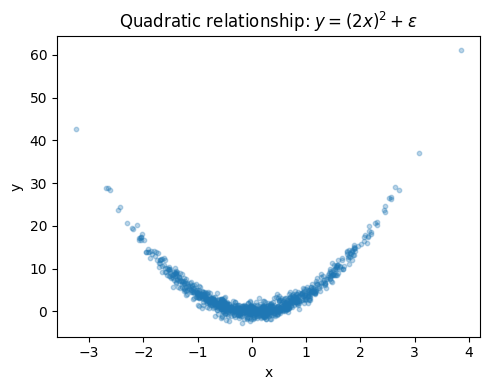

In [2]:
rng = np.random.RandomState(42)
N = 1000

x = rng.randn(N, 1)
y = (2 * x) ** 2 + rng.randn(N, 1)

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(x, y, alpha=0.3, s=10)
ax.set(xlabel="x", ylabel="y", title="Quadratic relationship: $y = (2x)^2 + \\varepsilon$")
fig.tight_layout()
plt.show()

## Linear correlation measures

All three classical correlations are near zero — they only measure
**monotonic** (Spearman/Kendall) or **linear** (Pearson) association.

In [3]:
pearson_r, pearson_p = stats.pearsonr(x.ravel(), y.ravel())
spearman_r, spearman_p = stats.spearmanr(x.ravel(), y.ravel())
kendall_tau, kendall_p = stats.kendalltau(x.ravel(), y.ravel())

print(f"Pearson:  r = {pearson_r:+.4f}  (p = {pearson_p:.3f})")
print(f"Spearman: r = {spearman_r:+.4f}  (p = {spearman_p:.3f})")
print(f"Kendall:  τ = {kendall_tau:+.4f}  (p = {kendall_p:.3f})")

Pearson:  r = +0.0991  (p = 0.002)
Spearman: r = +0.0089  (p = 0.780)
Kendall:  τ = -0.0020  (p = 0.924)


## Mutual Information via RBIG

Mutual Information $I(X; Y)$ captures **any** statistical dependence,
not just linear or monotonic. We estimate it by fitting three `AnnealedRBIG`
models: one on $X$, one on $Y$, and one on the joint $(X, Y)$.

In [4]:
model_x = AnnealedRBIG(
    n_layers=50,
    rotation="pca",
    random_state=42,
)
model_y = AnnealedRBIG(
    n_layers=50,
    rotation="pca",
    random_state=42,
)
model_xy = AnnealedRBIG(
    n_layers=50,
    rotation="pca",
    random_state=42,
)

model_x.fit(x)
model_y.fit(y)
model_xy.fit(np.hstack([x, y]))

mi = mutual_information_rbig(model_x, model_y, model_xy)
icc = np.sqrt(1 - np.exp(-2 * mi))

print(f"MI (RBIG): {mi:.4f} nats")
print(f"ICC:       {icc:.4f}")

MI (RBIG): 26.1151 nats
ICC:       1.0000


## Comparison: near-independent case

When we scale the signal down to $y = 0.01 \cdot (2x)^2 + \varepsilon$,
the dependence nearly vanishes — all metrics should be close to zero.

In [5]:
y_weak = 0.01 * (2 * x) ** 2 + rng.randn(N, 1)

# Linear measures
pearson_weak, _ = stats.pearsonr(x.ravel(), y_weak.ravel())
spearman_weak, _ = stats.spearmanr(x.ravel(), y_weak.ravel())

# RBIG MI
model_yw = AnnealedRBIG(n_layers=50, rotation="pca", random_state=42)
model_xyw = AnnealedRBIG(n_layers=50, rotation="pca", random_state=42)
model_yw.fit(y_weak)
model_xyw.fit(np.hstack([x, y_weak]))
mi_weak = mutual_information_rbig(model_x, model_yw, model_xyw)
icc_weak = np.sqrt(1 - np.exp(-2 * mi_weak))

print("=== Strong signal: y = (2x)^2 + noise ===")
print(f"  Pearson:  {pearson_r:+.4f}")
print(f"  Spearman: {spearman_r:+.4f}")
print(f"  MI:       {mi:.4f} nats")
print(f"  ICC:      {icc:.4f}")
print()
print("=== Weak signal: y = 0.01*(2x)^2 + noise ===")
print(f"  Pearson:  {pearson_weak:+.4f}")
print(f"  Spearman: {spearman_weak:+.4f}")
print(f"  MI:       {mi_weak:.4f} nats")
print(f"  ICC:      {icc_weak:.4f}")

=== Strong signal: y = (2x)^2 + noise ===
  Pearson:  +0.0991
  Spearman: +0.0089
  MI:       26.1151 nats
  ICC:      1.0000

=== Weak signal: y = 0.01*(2x)^2 + noise ===
  Pearson:  +0.0282
  Spearman: +0.0397
  MI:       16.0692 nats
  ICC:      1.0000


## Summary

| Metric | Strong signal | Weak signal |
|--------|:------------:|:-----------:|
| Pearson | ~0 | ~0 |
| Spearman | ~0 | ~0 |
| MI (RBIG) | **high** | ~0 |
| ICC | **high** | ~0 |

MI correctly detects the nonlinear quadratic dependence that linear
correlation entirely misses, and correctly shows near-zero dependence
when the signal is negligible.